# Wine Quality Prediction

#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import kagglehub

#### Downloading Dataset

In [2]:
path = kagglehub.dataset_download("sumit17125/red-wine-quality-dataset")
df = pd.read_csv(f"{path}/winequality-red.csv",sep=";")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Data OverView

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

### Data Cleaning

### EDA


#### Univariate Analysis

##### Target Variable Analysis

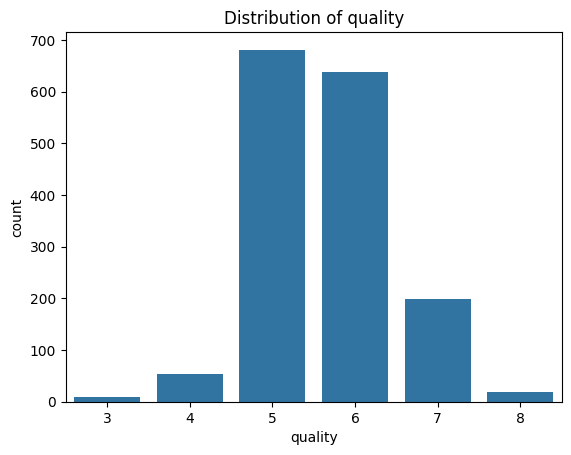

In [6]:
sns.countplot(df,x='quality')
plt.title('Distribution of quality')
plt.show()

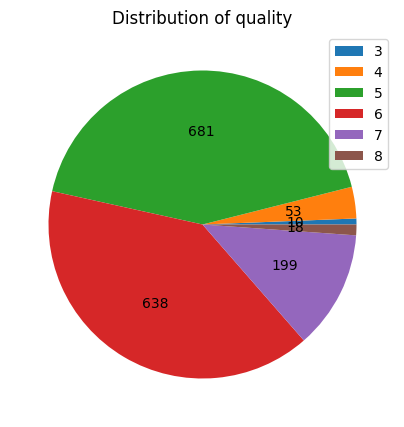

In [7]:
td = df.groupby('quality')

plt.figure(figsize=(5,5))
counts = td.size()

plt.pie(
    counts,
    autopct=lambda pct: f'{int(round(pct/100 * sum(counts)))}'
)

plt.title('Distribution of quality')
plt.legend(counts.index)
plt.show()

Observations
- High class imbalance

##### Feature Distributions Analysis

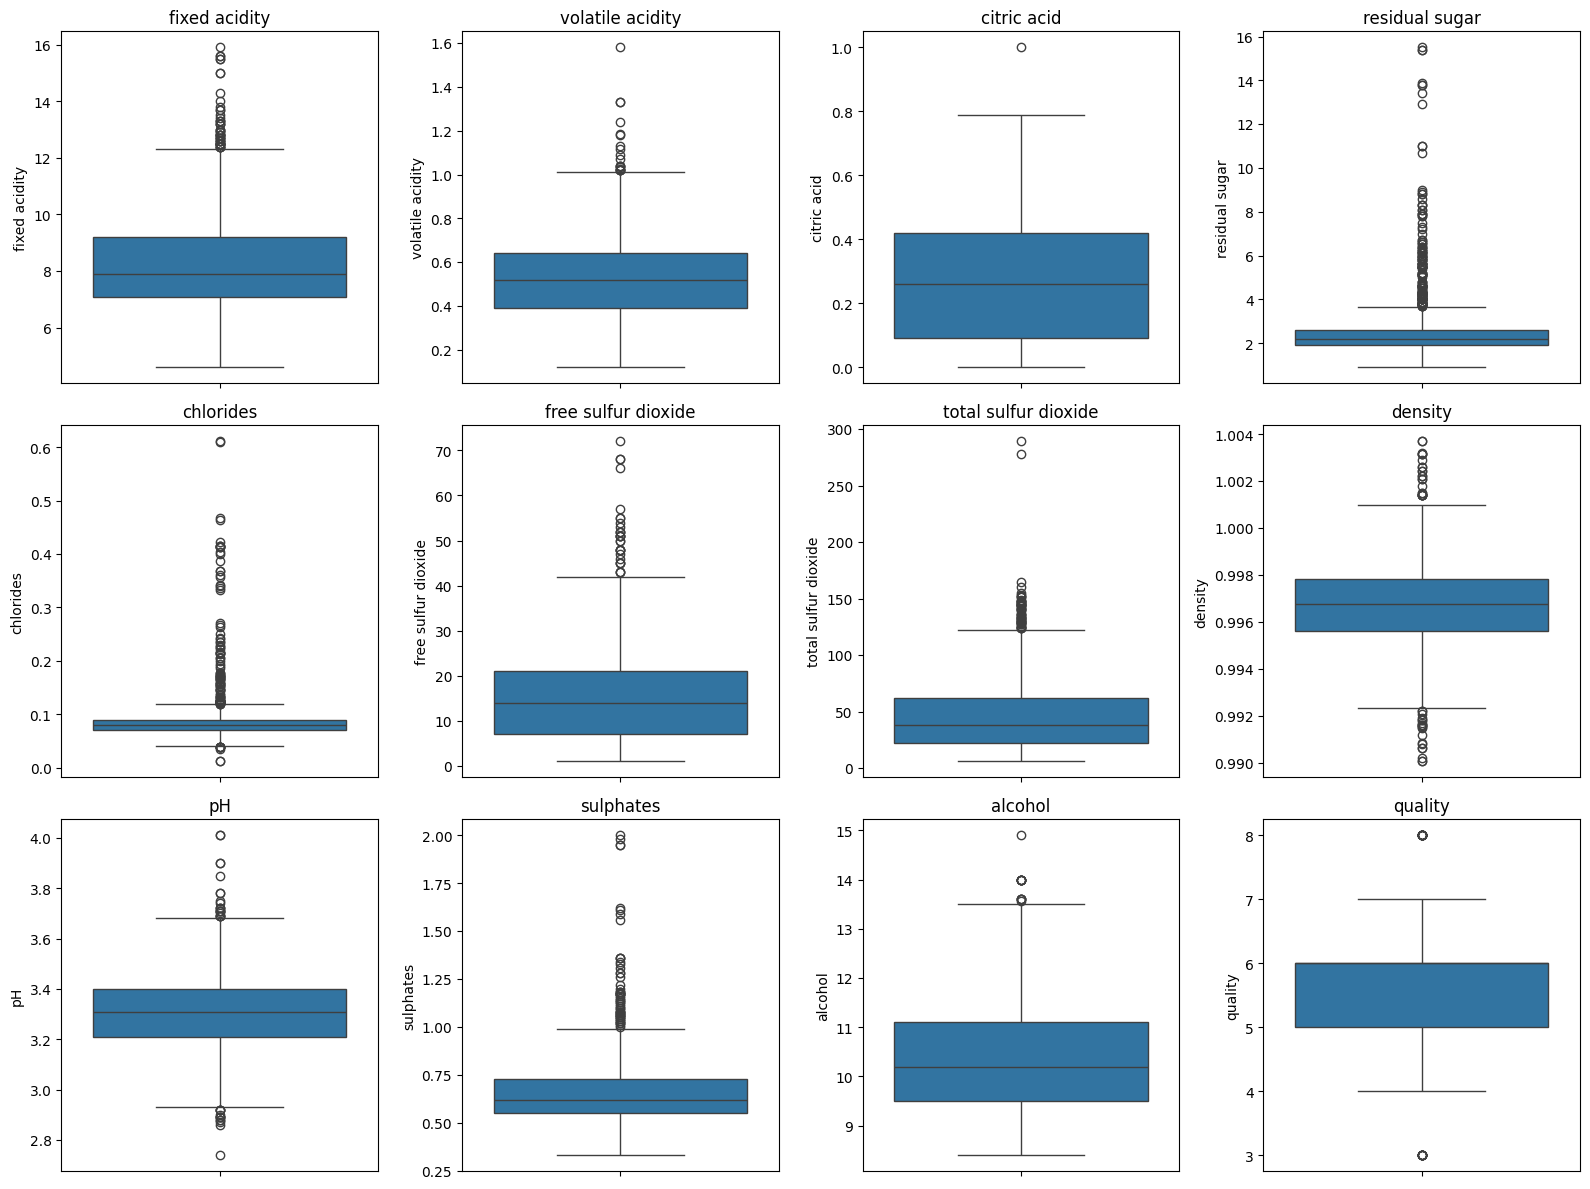

In [8]:
cols = df.columns
n = len(cols)

n_cols = 4
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

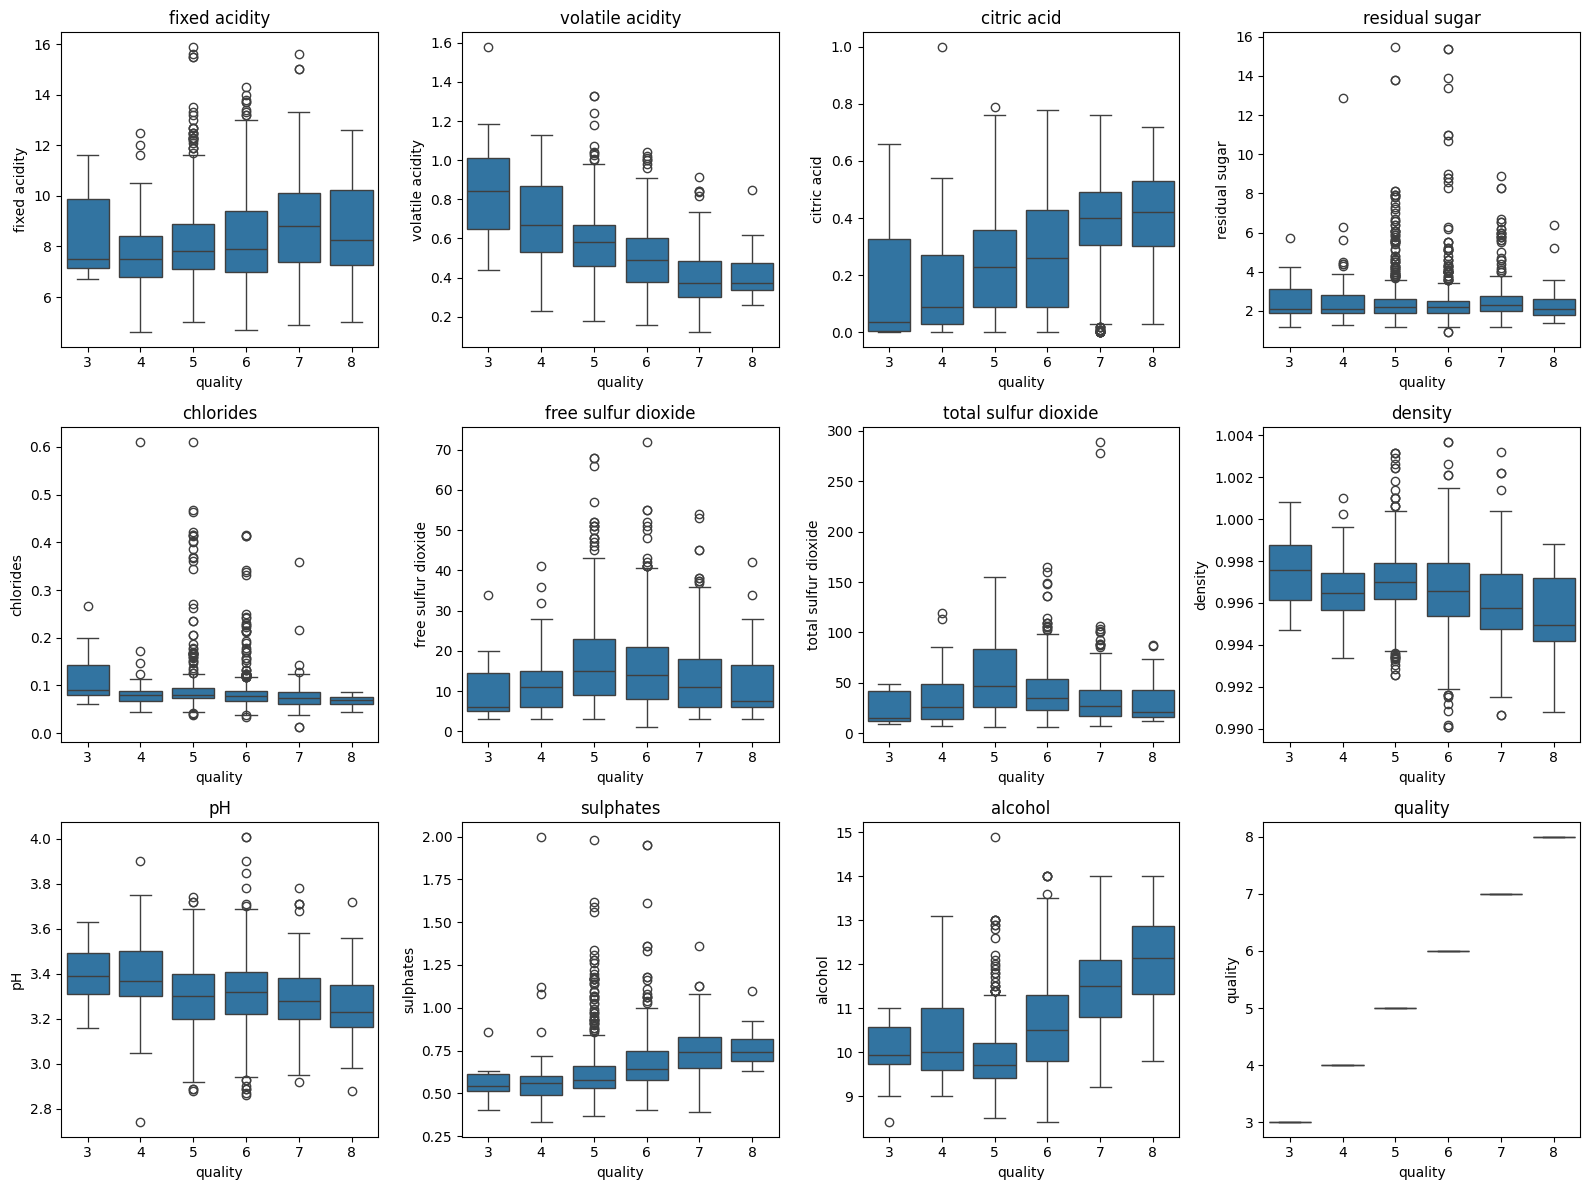

In [9]:
# As quality increases, this feature increases / decreases
cols = df.columns
n = len(cols)

# grid size
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df['quality'], y=df[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Observations
- Most Features are skewed and have many outliers
- volatile acidity, citric acid, sulphates, alcohol are the only features which have noticable difference in distribution (Q3-Q1) between top (7,8) and the rest of the wine quality

##### Splitting Dataset into top10 vs Bottom90

In [10]:
top10percent = int(df.shape[0]*10/100)
i = np.argsort(df['quality'])

df1 = df.iloc[i[df.shape[0] - top10percent:]]
df2 = df.iloc[i[:df.shape[0] - top10percent]]

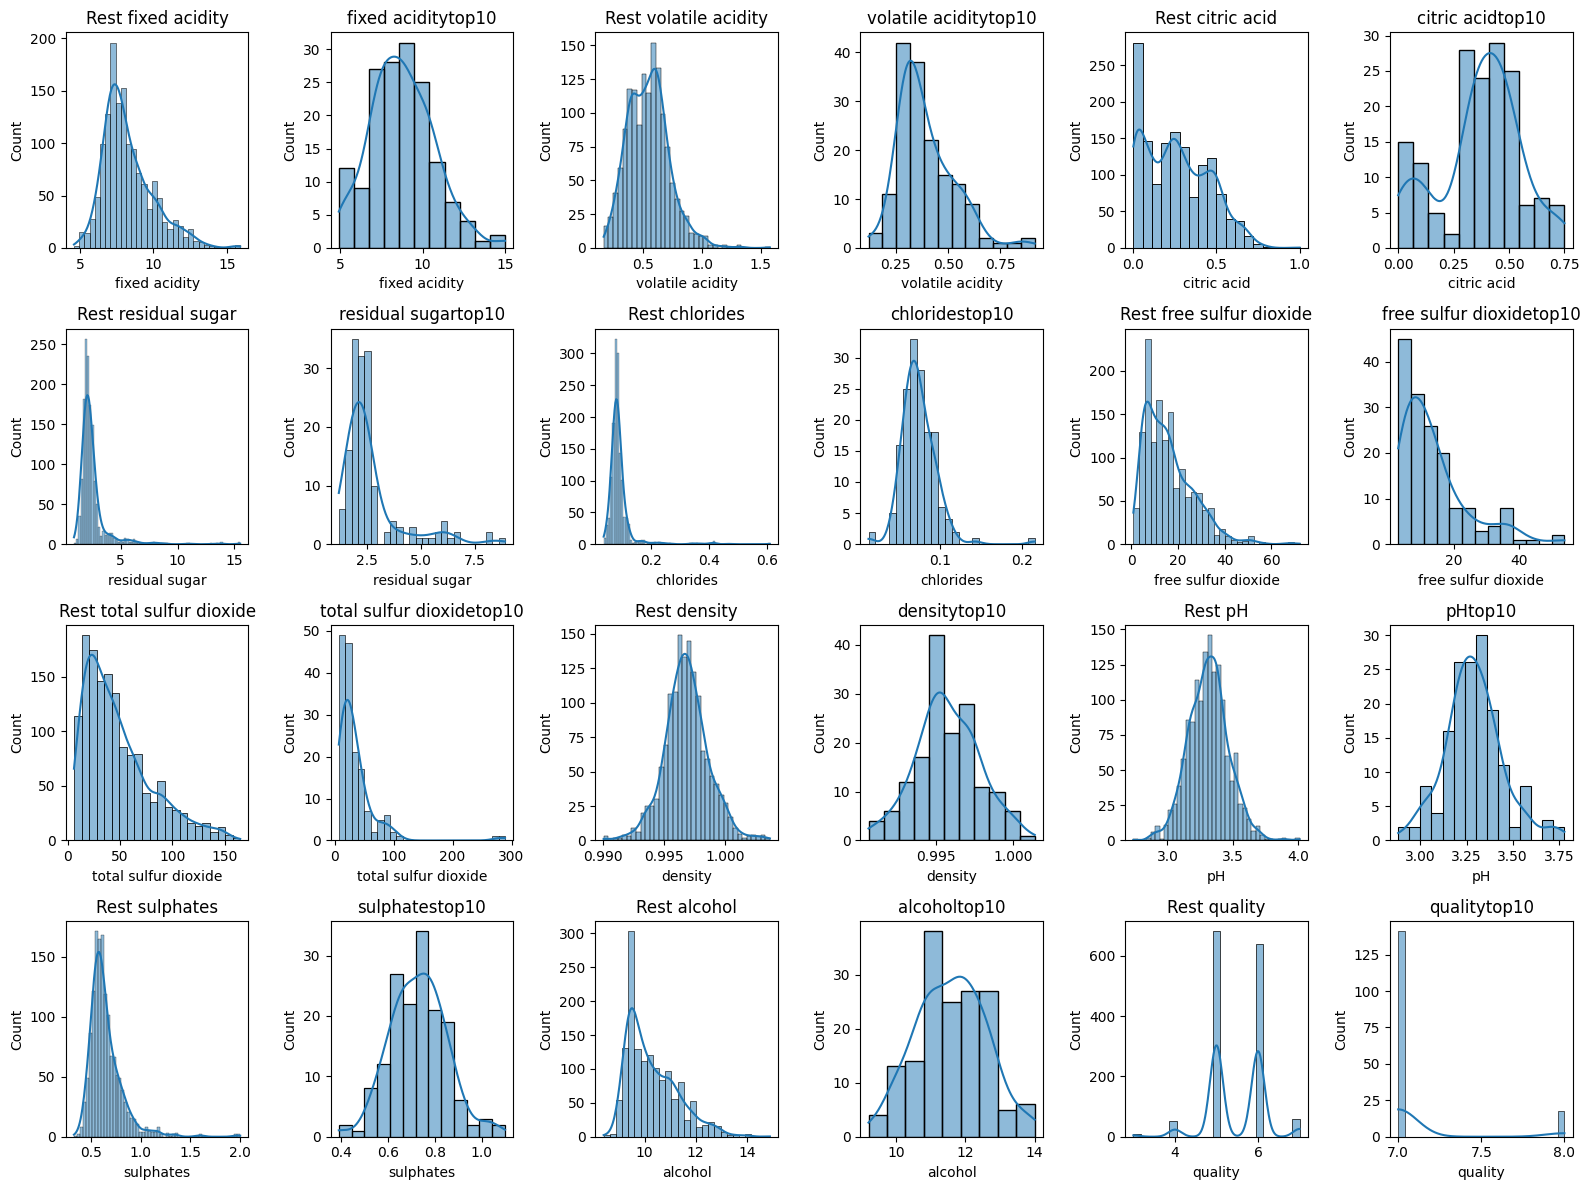

In [11]:
n = len(df.columns)

n_cols = 6
n_rows = 2*int(np.ceil(n/n_cols))

fig,axes = plt.subplots(n_rows, n_cols, figsize=(16,3*n_rows))

axes = axes.flatten()

for i,col in zip(np.arange(0,24,2),df.columns):
    sns.histplot(x=df2[col], ax=axes[i],kde=True)
    axes[i].set_title(f"Rest {col}")
    sns.histplot(x=df1[col],ax=axes[i+1],kde=True)
    axes[i+1].set_title(f"{col}top10")

plt.tight_layout()
plt.show()

Observations
- citric acid and alcohol have a slightly more noticeable difference between the top10 and rest distributions

#### Bivariate Analysis

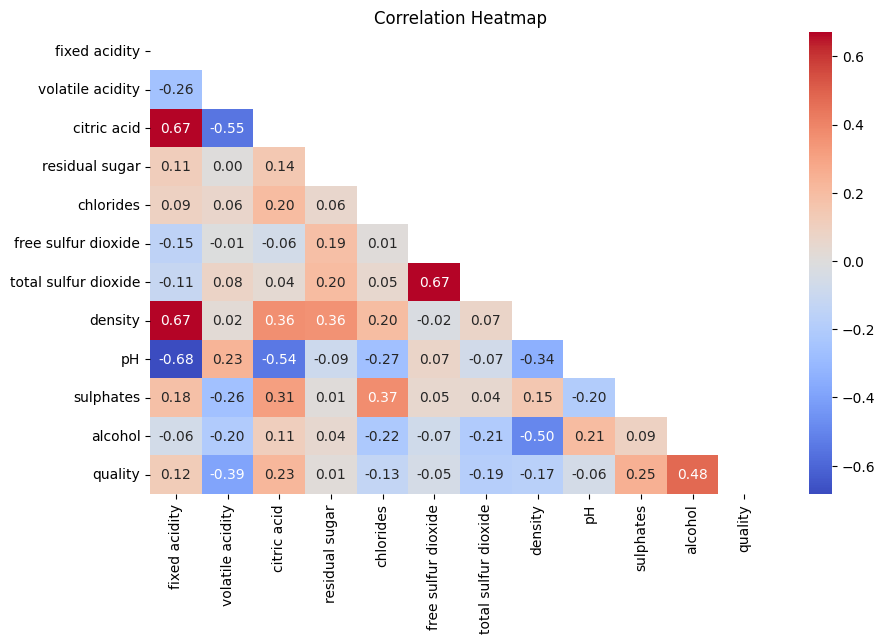

In [12]:
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10,6))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

Observations
- quality has high correlation with alcohol and volatile acidity
- volatile acidity has high correlation with  citric acid
- alcohol has high correlation with density

#### Conclusion

- High Class Imbalance in target variable
- Skewness and outliers in almost every feature
- Difference in distribution(boxplots) of top10% vs the rest 90% in volatile acidity, citric acid, sulphates, alcohol
- Difference in distribution(histogram) of top10% vs the rest 90% in citric acid and alcohol
- volatile acidity and citric acid highly correlated
- alcohol and citric acid have high correlation with target variable

features selected 
1. alcohol
2. citric acid
3. sulphates

> excluded volatile acidity due to high correlation with citric acid

### Data Preprocessing

In [13]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [14]:
features = ['alcohol','citric acid','sulphates']
X = df.drop(['quality', 'quality_label'], axis=1)[features]
y = df['quality_label']

### Model Training

In [15]:
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

##### KNN

In [16]:
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsClassifier())
])

param_grid = [
    {'scaler': [StandardScaler(), MinMaxScaler()],
     'knn__n_neighbors': list(range(1, 31)),
     'knn__weights': ['uniform', 'distance'],
     'knn__metric': ['euclidean', 'manhattan']}
]

grid = GridSearchCV(pipe,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1,
                    verbose=1
                    )


grid.fit(X_train, y_train)


print("Best Params:",grid.best_params_)
print("Best CV Score:",grid.best_score_)

print("Test accuracy:", grid.score(X_test,y_test))

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 22, 'knn__weights': 'distance', 'scaler': StandardScaler()}
Best CV Score: 0.9053982843137256
Test accuracy: 0.8875


In [17]:
scaler = StandardScaler()
X_train_new = scaler.fit_transform(X_train)
X_test_new = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=22,
                           leaf_size=10,
                           metric='manhattan',
                           weights='distance')
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

cr_knn = classification_report(y_test,y_pred)
print(cr_knn)

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       273
           1       0.66      0.45      0.53        47

    accuracy                           0.88       320
   macro avg       0.78      0.70      0.73       320
weighted avg       0.87      0.88      0.87       320



In [18]:
cm_knn = confusion_matrix(y_test,y_pred)
print(cr_knn)

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       273
           1       0.66      0.45      0.53        47

    accuracy                           0.88       320
   macro avg       0.78      0.70      0.73       320
weighted avg       0.87      0.88      0.87       320



##### Naive Bayes

In [19]:
pipe = Pipeline(steps=[
    ('preprocessing',FunctionTransformer(np.log1p)),
    ('model',GaussianNB())
])

score = cross_val_score(pipe,X_train,y_train, cv=5, scoring='accuracy')
print(score.mean(), score.std())

0.884295343137255 0.018853409432339388


In [20]:
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)
cr_naive = classification_report(y_test,y_pred)
cm_naive = confusion_matrix(y_test, y_pred)

print("Accuracy :",accuracy_score(y_test,y_pred))
print(cr_naive)
print(cm_naive)

Accuracy : 0.853125
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       273
           1       0.50      0.30      0.37        47

    accuracy                           0.85       320
   macro avg       0.69      0.62      0.65       320
weighted avg       0.83      0.85      0.84       320

[[259  14]
 [ 33  14]]


##### Random Forest

In [21]:
param_grid = [
    {'n_estimators':[50,100,150,200],
     'min_samples_split':[2,5,10,20],
     'max_features':['sqrt','log2']
     }
]

model_rf1 = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(model_rf1,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1,
                    verbose=1)

grid_rf.fit(X_train, y_train)


print("Best Params:",grid_rf.best_params_)
print("Best CV Score:",grid_rf.best_score_)
print("Test accuracy:", grid_rf.score(X_test,y_test))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params: {'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9061887254901961
Test accuracy: 0.878125


In [22]:
model_rf2 = RandomForestClassifier(max_features='sqrt',
                                   min_samples_split=2,
                                   n_estimators=200,
                                   random_state=42)
model_rf2.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [23]:
y_pred_rf = model_rf2.predict(X_test)
cr_rf = classification_report(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test,y_pred_rf)
print(cr_rf)
print(cm_rf)

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       273
           1       0.61      0.47      0.53        47

    accuracy                           0.88       320
   macro avg       0.76      0.71      0.73       320
weighted avg       0.87      0.88      0.87       320

[[259  14]
 [ 25  22]]


##### Logistic Regression

In [24]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0, 1],     
    'solver': ['liblinear']
}

In [25]:
model_lr = LogisticRegression(max_iter = 1000,class_weight='balanced')

grid_lr = GridSearchCV(model_lr,
                       param_grid_lr,
                       cv=5,scoring='accuracy',
                       n_jobs=-1,
                       verbose=1)

grid_lr.fit(X_train, y_train)

print("Best Params:",grid_lr.best_params_)
print("Best CV Score:",grid_lr.best_score_)
print("Test accuracy:", grid_lr.score(X_test,y_test))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'C': 1, 'l1_ratio': 1, 'solver': 'liblinear'}
Best CV Score: 0.7685386029411765
Test accuracy: 0.79375


In [26]:
model_lr = LogisticRegression(C=1,
                              max_iter=1000,
                              l1_ratio=1,
                              solver='liblinear',
                              class_weight='balanced')
model_lr.fit(X_train,y_train)

y_pred_lr = model_lr.predict(X_test)

cr_lr = classification_report(y_test,y_pred_lr)
cm_lr = confusion_matrix(y_test,y_pred_lr)
print(cr_lr)
print(cm_lr)

              precision    recall  f1-score   support

           0       0.96      0.79      0.87       273
           1       0.40      0.83      0.54        47

    accuracy                           0.79       320
   macro avg       0.68      0.81      0.70       320
weighted avg       0.88      0.79      0.82       320

[[215  58]
 [  8  39]]


### Models Evaluation



**Confusion Matrix**

|                | Predicted 0 | Predicted 1 |
|----------------|-------------|-------------|
| **Actual 0**   | TN          | FP          |
| **Actual 1**   | FN          | TP          |

- **TP** (True Positive) — predicted positive, actually positive
- **TN** (True Negative) — predicted negative, actually negative
- **FP** (False Positive) — predicted positive, actually negative
- **FN** (False Negative) — predicted negative, actually positive

**Precision** — of all predicted positives, how many were correct:

$$
Precision = \frac{TP}{TP + FP}
$$

**Recall** — of all actual positives, how many were correctly identified:

$$
Recall = \frac{TP}{TP + FN}
$$

In [27]:
print('KNN')
print(cr_knn)
print(cm_knn)

KNN
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       273
           1       0.66      0.45      0.53        47

    accuracy                           0.88       320
   macro avg       0.78      0.70      0.73       320
weighted avg       0.87      0.88      0.87       320

[[262  11]
 [ 26  21]]


In [28]:
print('Naive Bayes')
print(cr_naive)
print(cm_naive)

Naive Bayes
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       273
           1       0.50      0.30      0.37        47

    accuracy                           0.85       320
   macro avg       0.69      0.62      0.65       320
weighted avg       0.83      0.85      0.84       320

[[259  14]
 [ 33  14]]


In [29]:
print('Random Forest')
print(cr_rf)
print(cm_rf)

Random Forest
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       273
           1       0.61      0.47      0.53        47

    accuracy                           0.88       320
   macro avg       0.76      0.71      0.73       320
weighted avg       0.87      0.88      0.87       320

[[259  14]
 [ 25  22]]


In [30]:
print('Logistic Regression')
print(cr_lr)
print(cm_lr)

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.79      0.87       273
           1       0.40      0.83      0.54        47

    accuracy                           0.79       320
   macro avg       0.68      0.81      0.70       320
weighted avg       0.88      0.79      0.82       320

[[215  58]
 [  8  39]]


Precision and recall
- Due to heavy class imbalance , all models are good at predicting bad wine quality 

KNN and Random Forest give comparable results for Good wine quality 
- KNN predicts a bit less False postives than random forest
- Random forest predicts a bit less False negatives than KNN

Logistic Regression is far better at predicting True negatives than false ones
